In [164]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [165]:
import polyphase as phase
import numpy as np
import math as mt
import csv

In [166]:
def load_database(filename):
    with open(filename, mode='r', newline='') as file:
        reader = csv.DictReader(file)
        return {row['Compound'].strip().lower(): row for row in reader}

In [167]:
A = load_database('Green_Solvents.csv')
A

{'anisole': OrderedDict([('Compound', 'Anisole'),
              ('Molar Volume (cm^3/mol)', '108.68'),
              ('Molar Mass (g/mol)', '108.14'),
              ('Density g/cm^3', '1.00'),
              ('dD', '17.8'),
              ('dP', '4.4'),
              ('dH', '6.9'),
              ('R', '6.24'),
              ('RED_F4TCNQ', '0.69'),
              ('RED_PBTTT', '1.35')]),
 'o-xylene': OrderedDict([('Compound', 'o-Xylene'),
              ('Molar Volume (cm^3/mol)', '120.78'),
              ('Molar Mass (g/mol)', '106.17'),
              ('Density g/cm^3', '0.88'),
              ('dD', '18.0'),
              ('dP', '2.6'),
              ('dH', '2.8'),
              ('R', '7.69'),
              ('RED_F4TCNQ', '0.85'),
              ('RED_PBTTT', '0.86')]),
 'thf': OrderedDict([('Compound', 'THF'),
              ('Molar Volume (cm^3/mol)', '81.24'),
              ('Molar Mass (g/mol)', '72.11'),
              ('Density g/cm^3', '0.89'),
              ('dD', '16.8'),
           

In [169]:
solvents = list(A.keys())
solvents = np.delete(solvents, [9, 10, 11])  # remove useless rows


hansen_s = np.array([
    [float(A[s]['Molar Volume (cm^3/mol)']),float(A[s]['dD']), float(A[s]['dP']), float(A[s]['dH'])]
    for s in solvents])

In [170]:
T = 298.15 # K
R = 8.314 # J/(mol*K)

In [171]:
Dopant = 'f4tcnq'
Polymer = 'pbttt'

V_d = float(A[Dopant]['Molar Volume (cm^3/mol)']) # cm^3/mol
V_p = float(A[Polymer]['Molar Volume (cm^3/mol)']) # cm^3/mol

dD_d = float(A[Dopant]['dD']) # MPa^1/2
dP_d = float(A[Dopant]['dP']) # MPa^1/2
dH_d = float(A[Dopant]['dH']) # MPa^1/2

dD_p = float(A[Polymer]['dD'])  #
dP_p = float(A[Polymer]['dP'])  
dH_p = float(A[Polymer]['dH'])  

In [172]:
B = list(A.keys())
np.delete(B, [9,10,11])

array(['anisole', 'o-xylene', 'thf', 'dmso', 'acetone', 'acn', 'nba',
       'cyrene', 'nmp'], dtype='<U8')

In [173]:
n = len(hansen_s)

Radius = np.zeros((n, 3))
N = np.zeros((n, 3))
X = np.zeros((n, 3))
X_cr = np.zeros((n, 3))

for i in range(n):
    Radius[i, 0] = mt.sqrt(4*(dD_p - hansen_s[i,1])**2 + (dP_p - hansen_s[i,2])**2 + (dH_p - hansen_s[i,3])**2)  # polymer vs solvent 
    Radius[i, 1] = mt.sqrt(4*(dD_d - hansen_s[i,1])**2 + (dP_d - hansen_s[i,2])**2 + (dH_d - hansen_s[i,3])**2)  # dopant vs solvent 
    Radius[i, 2] = mt.sqrt(4*(dD_p - dD_d)**2 + (dP_p - dP_d)**2 + (dH_p - dH_d)**2) # polymer vs solvent

    N[i, 0] = V_p / hansen_s[i, 0]
    N[i, 1] = V_d / hansen_s[i, 0]
    N[i, 2] = 1

    X[i, 0] = (hansen_s[i,0] * Radius[i,0]**2 / (4*R*T)) + 0.2 # 0 # 0.1
    X[i, 1] = (hansen_s[i,0] * Radius[i,1]**2 / (4*R*T)) + 0.34
    X[i, 2] = (hansen_s[i,0] * Radius[i,2]**2 / (4*R*T))

    X12_cr = 1/2 * (1/mt.sqrt(N[i,0]) + 1/mt.sqrt(N[i,1]))**2
    X13_cr = 1/2 * (1/mt.sqrt(N[i,0]) + 1/mt.sqrt(N[i,2]))**2
    X23_cr = 1/2 * (1/mt.sqrt(N[i,2]) + 1/mt.sqrt(N[i,1]))**2
    X_cr[i] = [X13_cr, X12_cr, X23_cr]

In [174]:
Crit = np.zeros((n, 3))  

for i in range(n):
    for j in range(3):
        if X[i, j] >= X_cr[i, j]:
            Crit[i, j] = 1
        else:
            Crit[i, j] = 0

Crit

array([[0., 0., 0.],
       [0., 1., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 0.],
       [1., 1., 0.],
       [0., 1., 0.],
       [1., 1., 0.],
       [1., 0., 0.]])

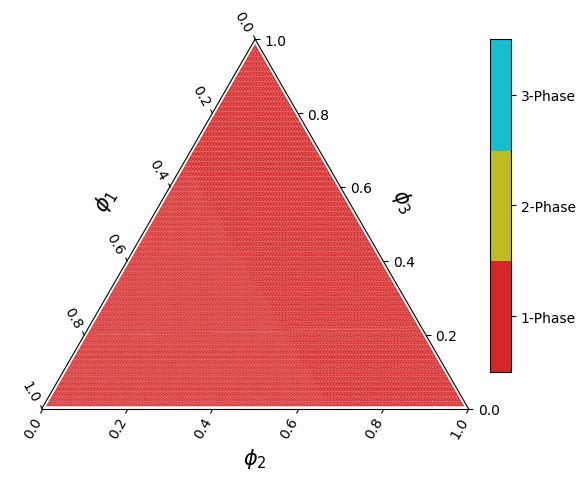

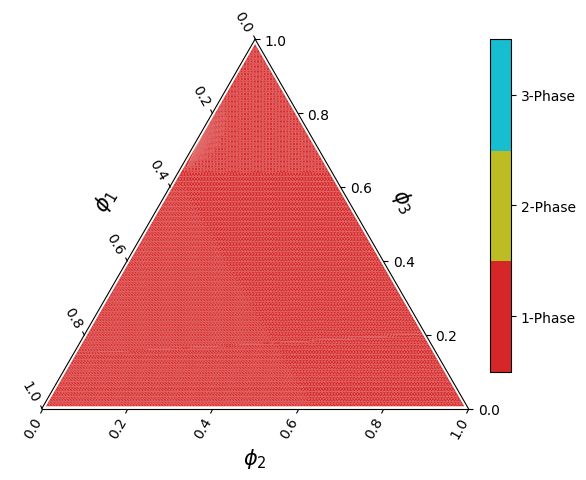

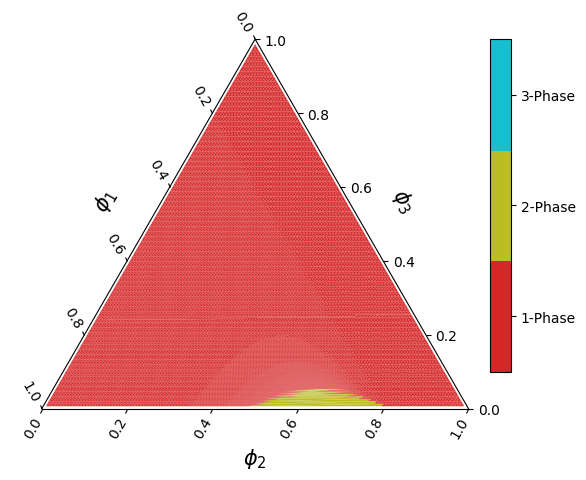

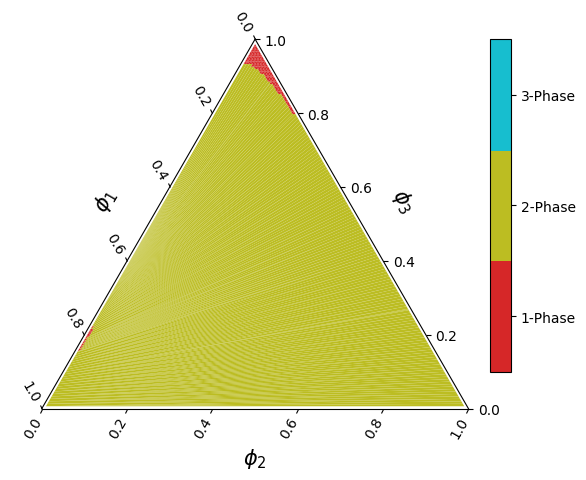

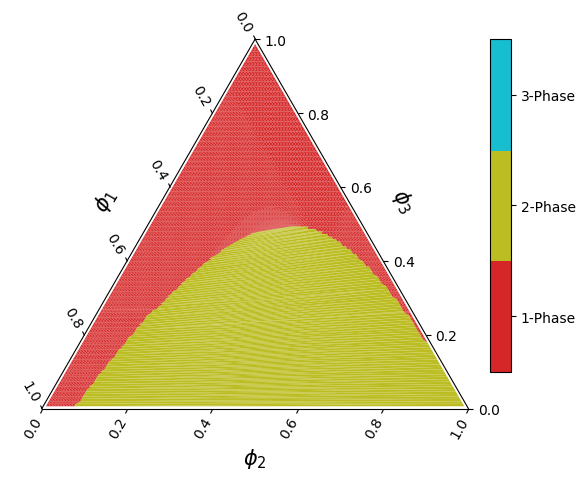

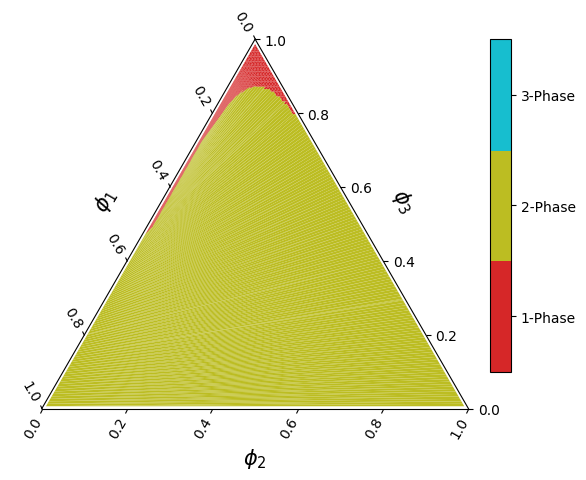

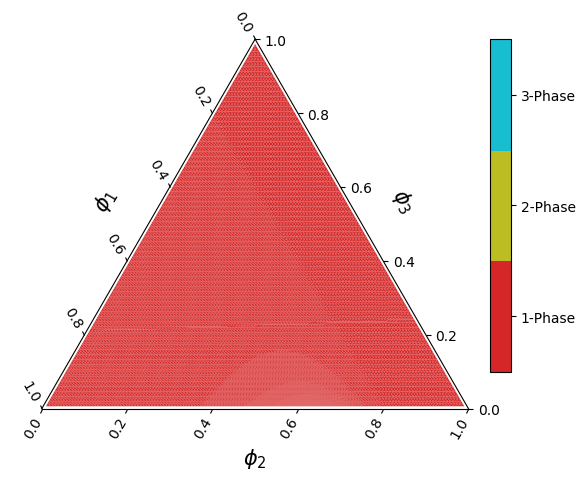

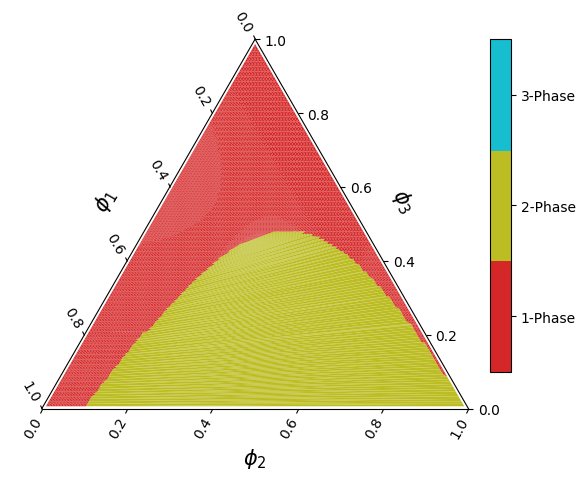

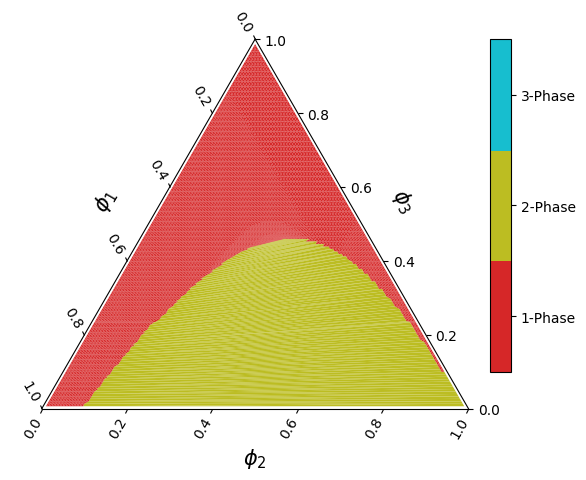

In [175]:
import matplotlib.pyplot as plt

B = list(A.keys())
np.delete(B, [9,10,11])

engines = []
id = 0;
for i in range(n):
    M = N[i, :]
    chi = X[i, :]
    f = lambda x, M=M, chi=chi: phase.flory_huggins(x, M, chi) 
    engine = phase.PHASE(f, 150, 3)
    engine.compute(use_parallel=False, verbose=False, lift_label=True) 
    engine.plot(filename=f"{B[id]}.png")
    id = id + 1

In [176]:
N

array([[ 5.59072506,  1.48813029,  1.        ],
       [ 5.03063421,  1.3390462 ,  1.        ],
       [ 7.47907435,  1.99076809,  1.        ],
       [ 8.55774648,  2.27788732,  1.        ],
       [ 8.20748345,  2.18465487,  1.        ],
       [11.63316102,  3.09649627,  1.        ],
       [ 6.63971151,  1.76734783,  1.        ],
       [ 5.91510903,  1.5744743 ,  1.        ],
       [ 6.30094369,  1.67717515,  1.        ]])

In [177]:
hansen_s

array([[108.68,  17.8 ,   4.4 ,   6.9 ],
       [120.78,  18.  ,   2.6 ,   2.8 ],
       [ 81.24,  16.8 ,   5.7 ,   8.  ],
       [ 71.  ,  18.4 ,  16.4 ,  10.2 ],
       [ 74.03,  15.5 ,  10.4 ,   7.  ],
       [ 52.23,  15.3 ,  18.  ,   6.1 ],
       [ 91.51,  15.8 ,   3.7 ,   6.3 ],
       [102.72,  18.9 ,  12.4 ,   7.1 ],
       [ 96.43,  18.  ,  12.3 ,   7.2 ]])

In [178]:
Radius

array([[ 4.74236228,  6.24659907,  7.78267306],
       [ 1.356466  ,  7.69220385,  7.78267306],
       [ 6.95485442,  5.26877595,  7.78267306],
       [15.23679756,  9.78212656,  7.78267306],
       [10.47091209,  3.40147027,  7.78267306],
       [16.57860066,  8.99444273,  7.78267306],
       [ 6.73052747,  6.26178888,  7.78267306],
       [10.25914226,  6.22414653,  7.78267306],
       [10.26693723,  4.96789694,  7.78267306]])

In [179]:
X

array([[0.44650984, 0.76769293, 0.66389956],
       [0.22241341, 1.06076181, 0.7378155 ],
       [0.59631561, 0.56744927, 0.4962753 ],
       [1.86242063, 1.0252043 , 0.43372165],
       [1.0186004 , 0.42638459, 0.45223118],
       [1.6478079 , 0.76615121, 0.3190603 ],
       [0.61808244, 0.70187666, 0.55901222],
       [1.29036597, 0.74133756, 0.62749137],
       [1.2251541 , 0.5800228 , 0.5890673 ]])

In [180]:
X_cr

array([[1.01236134, 0.77211923, 1.65573849],
       [1.0452409 , 0.85808392, 1.73757615],
       [0.93251203, 0.5771712 , 1.45990378],
       [0.90026456, 0.50442092, 1.38207486],
       [0.90997592, 0.52594761, 1.40543263],
       [0.83617191, 0.37106908, 1.2297559 ],
       [0.96338817, 0.65013462, 1.53511958],
       [0.99569665, 0.72977629, 1.6145184 ],
       [0.97773289, 0.68508886, 1.57028653]])